In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Data loaded:", x_train.shape, x_test.shape)

Data loaded: (50000, 32, 32, 3) (10000, 32, 32, 3)


In [ ]:
# Underfitting Model - Very simple architecture
def create_underfit_model():
    model = Sequential([
        Conv2D(16, (3,3), activation='relu', input_shape=(32,32,3)),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

under_model = create_underfit_model()
under_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

print("Training Underfitting Model...")
under_history = under_model.fit(x_train, y_train,
                                epochs=15,
                                batch_size=64,
                                validation_data=(x_test, y_test),
                                verbose=1)

Training Underfitting Model...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3663 - loss: 1.7370 - val_accuracy: 0.4479 - val_loss: 1.5241
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4711 - loss: 1.4651 - val_accuracy: 0.4905 - val_loss: 1.4073
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5101 - loss: 1.3606 - val_accuracy: 0.5179 - val_loss: 1.3467
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5401 - loss: 1.2916 - val_accuracy: 0.5216 - val_loss: 1.3505
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5571 - loss: 1.2429 - val_accuracy: 0.5224 - val_loss: 1.3257
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5744 - loss: 1.2032 - val_accuracy: 0.5578 - val_loss: 1.2409
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5847 - loss: 1.1762 - val_accuracy: 0.5674 - val_loss: 1.2221
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5956 - 

In [ ]:
# Overfitting Model - Deep + Large dense layers
def create_overfit_model():
    model = Sequential([
        Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
        Conv2D(128, (3,3), activation='relu'),
        Conv2D(256, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(512, (3,3), activation='relu'),
        Flatten(),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

over_model = create_overfit_model()
over_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print("Training Overfitting Model...")
over_history = over_model.fit(x_train, y_train,
                              epochs=25,       # Longer training
                              batch_size=64,
                              validation_data=(x_test, y_test),
                              verbose=1)

Training Overfitting Model...
Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 51ms/step - accuracy: 0.4417 - loss: 1.5244 - val_accuracy: 0.5443 - val_loss: 1.2517
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.6534 - loss: 0.9775 - val_accuracy: 0.6891 - val_loss: 0.8874
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.7481 - loss: 0.7246 - val_accuracy: 0.7264 - val_loss: 0.8047
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.8094 - loss: 0.5387 - val_accuracy: 0.7193 - val_loss: 0.8655
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.8690 - loss: 0.3750 - val_accuracy: 0.7205 - val_loss: 0.9272
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.9120 - loss: 0.2536 - val_accuracy: 0.7210 - val_loss: 1.0793
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.9406 - loss: 0.1742 - val_accuracy: 0.7147 - val_loss: 1.2812
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accu

In [ ]:
# L2 Regularized Model
def create_reg_model():
    model = Sequential([
        Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(32,32,3)),
        MaxPooling2D((2,2)),
        Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(10, activation='softmax')
    ])
    return model

reg_model = create_reg_model()
reg_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("Training Regularized (L2) Model...")
reg_history = reg_model.fit(x_train, y_train,
                            epochs=25,
                            batch_size=64,
                            validation_data=(x_test, y_test),
                            verbose=1)

Training Regularized (L2) Model...
Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.4636 - loss: 1.6336 - val_accuracy: 0.5555 - val_loss: 1.3961
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5841 - loss: 1.3317 - val_accuracy: 0.6104 - val_loss: 1.2835
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6297 - loss: 1.2344 - val_accuracy: 0.6521 - val_loss: 1.2002
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6544 - loss: 1.1787 - val_accuracy: 0.6689 - val_loss: 1.1559
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6754 - loss: 1.1274 - val_accuracy: 0.6724 - val_loss: 1.1541
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6902 - loss: 1.0950 - val_accuracy: 0.6829 - val_loss: 1.1254
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7072 - loss: 1.0590 - val_accuracy: 0.6885 - val_loss: 1.1117
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7

In [ ]:
# Dropout Model
def create_dropout_model():
    model = Sequential([
        Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
        MaxPooling2D((2,2)),
        Dropout(0.25),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Dropout(0.25),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

drop_model = create_dropout_model()
drop_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print("Training Dropout Model...")
drop_history = drop_model.fit(x_train, y_train,
                              epochs=25,
                              batch_size=64,
                              validation_data=(x_test, y_test),
                              verbose=1)

Training Dropout Model...
Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4198 - loss: 1.5944 - val_accuracy: 0.5716 - val_loss: 1.2288
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5577 - loss: 1.2481 - val_accuracy: 0.6372 - val_loss: 1.0486
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6099 - loss: 1.1122 - val_accuracy: 0.6596 - val_loss: 0.9848
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6402 - loss: 1.0280 - val_accuracy: 0.6873 - val_loss: 0.9063
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6591 - loss: 0.9715 - val_accuracy: 0.6947 - val_loss: 0.8728
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6784 - loss: 0.9190 - val_accuracy: 0.7060 - val_loss: 0.8552
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6901 - loss: 0.8855 - val_accuracy: 0.7175 - val_loss: 0.8169
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7038 - los

In [ ]:
# Combined Model
def create_combined_model():
    model = Sequential([
        Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(32,32,3)),
        MaxPooling2D((2,2)),
        Dropout(0.25),
        Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
        MaxPooling2D((2,2)),
        Dropout(0.25),
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

combined_model = create_combined_model()
combined_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

print("Training Combined (L2 + Dropout) Model...")
combined_history = combined_model.fit(x_train, y_train,
                                      epochs=25,
                                      batch_size=64,
                                      validation_data=(x_test, y_test),
                                      verbose=1)

Training Combined (L2 + Dropout) Model...
Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.3939 - loss: 1.8170 - val_accuracy: 0.5228 - val_loss: 1.4820
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5068 - loss: 1.5326 - val_accuracy: 0.5877 - val_loss: 1.3607
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5495 - loss: 1.4584 - val_accuracy: 0.6060 - val_loss: 1.3134
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5679 - loss: 1.4157 - val_accuracy: 0.6056 - val_loss: 1.3178
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5812 - loss: 1.3837 - val_accuracy: 0.6348 - val_loss: 1.2662
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5943 - loss: 1.3607 - val_accuracy: 0.6366 - val_loss: 1.2602
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6057 - loss: 1.3401 - val_accuracy: 0.6610 - val_loss: 1.2162
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accura

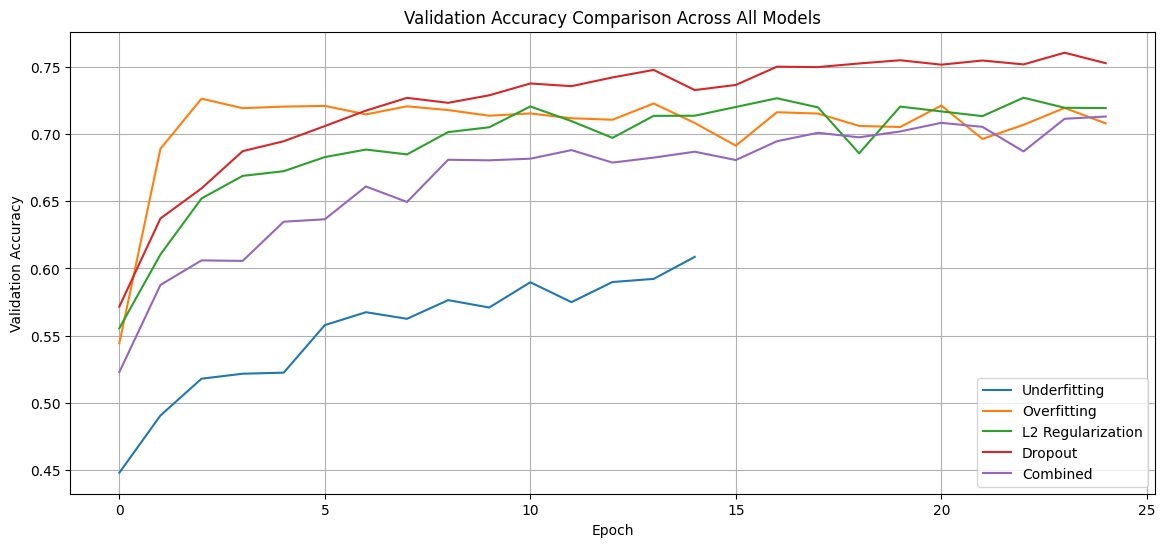

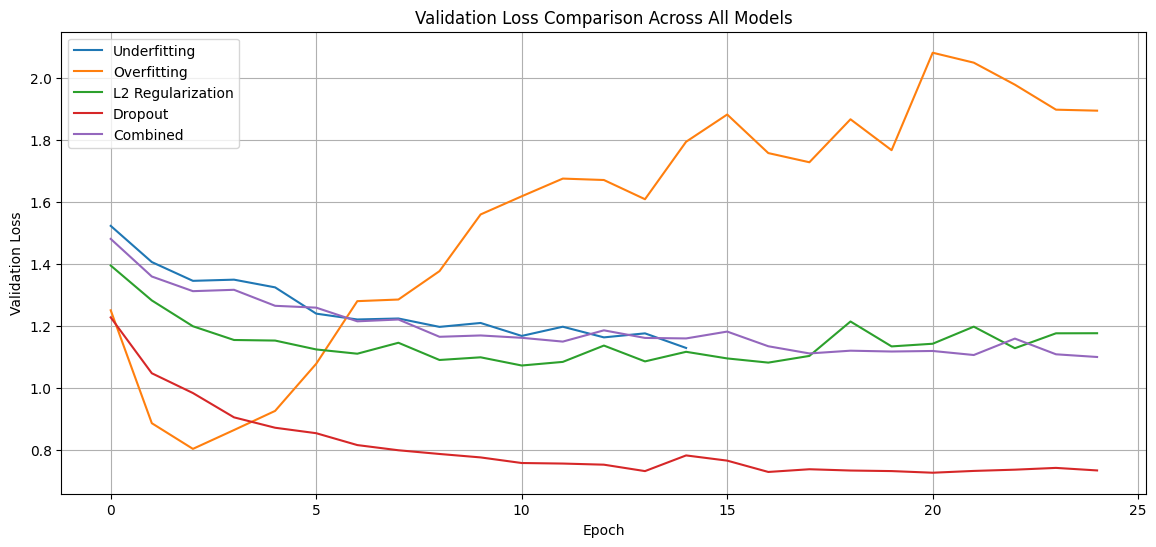

In [ ]:
histories = {
    "Underfitting": under_history,
    "Overfitting": over_history,
    "L2 Regularization": reg_history,
    "Dropout": drop_history,
    "Combined": combined_history
}

# Accuracy Comparison
plt.figure(figsize=(14, 6))
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison Across All Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Comparison
plt.figure(figsize=(14, 6))
for name, hist in histories.items():
    plt.plot(hist.history['val_loss'], label=name)
plt.title('Validation Loss Comparison Across All Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("\n=== Final Test Accuracy Comparison ===")
for name, model in zip(histories.keys(),
                       [under_model, over_model, reg_model, drop_model, combined_model]):
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{name:20s}: {acc:.4f} ({acc*100:.2f}%)")


=== Final Test Accuracy Comparison ===
Underfitting        : 0.6086 (60.86%)
Overfitting         : 0.7080 (70.80%)
L2 Regularization   : 0.7194 (71.94%)
Dropout             : 0.7528 (75.28%)
Combined            : 0.7131 (71.31%)
